## Iterative methods for the discrete Helmholtz equation leading to complex symmetric matrices

This notebook implements the finite difference discretization of a complex Helmholtz equation and compares direct and iterative solvers, including Gauss-Seidel, COCG, GMRES, and preconditioned variants. The complex Helmholtz equation is defined as
\begin{equation*}
\begin{aligned}-\frac{\partial^2 u}{\partial x^2} - \frac{\partial^2 u}{\partial y^2} -c(x,y)\hat{i}u & = f(x,y) \, \, \text{ for } (x,y)\in \Omega, \\
u & = g(x,y) \, \, \text{ on } (x,y)\in \partial \Omega,
\end{aligned}
\end{equation*}
where $\Omega = (0,1)^2$. We choose $c(x,y) = 2$, and $f(x,y)$ and $g(x,y)$ such that 
$$u_{ex} = x(1-x)y^3(1-y)+e^x$$
is the exact solution. The domain is discretized using a uniform finite difference grid with mesh size
$$
h=\frac{1}{N}.
$$
The iterative methods are terminated once the relative residual satisfies
$$ \dfrac{||r_k||_\infty}{||f||_{\infty}} \leq 10^{-6} $$
or if we have iterated a maximum of 100000 times. This criterion ensures that the residual is sufficiently small relative to the right-hand side.
<br>
<br> 
To study asymptotic convergence behavior, the reduction factor is computed as
$$ \text{red}_k = \dfrac{||r_k||_\infty}{||r_{k-1}||_{\infty}}. $$
As the iteration progresses, this quantity approaches the spectral radius of the iteration matrix.

## Running the Experiments

The solver can be selected by setting the variable `solver` to one of the following values:

- `0` : Direct Method
- `1` : Gauss-Seidel
- `2` : COCG
- `3` : GMRES
- `4` : PCOCG (real part Incomplete Cholesky preconditioner)
- `5` : PGMRES (Incomplete Cholesky preconditioner)

In [86]:
# Different numbers are different solvers. 0 is Direct Method, 1 is Gauss Seidel, 2 is COCG, 3 is GMRES, 4 is PCOCG, 5 is PGMRES
solver = 4

### Importing libraries

In [87]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
import time
import scipy.sparse as sp
from scipy.sparse.linalg import spsolve, splu
from typing import Tuple

### Initializing parameters

In [88]:
N_list = [16, 32, 64, 128, 256]
x_mesh = np.linspace(0, 1, 101)
y_mesh = np.linspace(0, 1, 101)
names = ["a direct method", "Gauss-Seidel", "COCG", "GMRES", "PCOCG", "PGMRES"]

### Plotting the exact solution

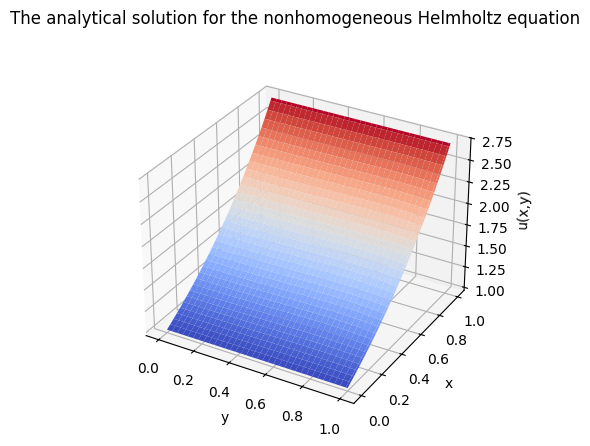

In [89]:
def u_exact(x: np.ndarray, y: np.ndarray) -> np.ndarray:
    """
    The analytical solution for the nonhomogeneous Helmholtz equation.

    Parameters:
    x (np.ndarray): x values.
    y (np.ndarray): y values.
    
    Returns:
    u (np.ndarray): the analytical solution evaluated in the x and y values.
    """
    u = np.zeros((len(x),len(y)))
    for i, y_elt in enumerate(y):
        u[i,:] = x * (1-x) * y_elt**3 * (1-y_elt) + np.exp(x)
    return u

u_analytical = u_exact(x_mesh,y_mesh)

fig, ax = plt.subplots(subplot_kw={"projection": "3d"})
XX, YY = np.meshgrid(x_mesh, y_mesh)
surf = ax.plot_surface(YY, XX, u_analytical, cmap=cm.coolwarm)

plt.xlabel(r"y")
ax.set_zlabel(r"u(x,y)")
plt.ylabel(r"x")
plt.suptitle("The analytical solution for the nonhomogeneous Helmholtz equation")
plot_handles_12 = (fig, [ax])

### The functions f(x,y), g(x,y) and c(x,y)

In [90]:
def f(x: float, y: float) -> float: 
    """
    The source term f(x,y).

    Parameters:
        x (float): x value.
        y (float): y value:

    Returns:
        f (float): f value.
    """
    return -1*(2*y**3*(y-1) + np.exp(x) + 6 *x*y*(x-1)*(2*y-1)) - 2j*(x*(1-x)*y**3*(1-y) + np.exp(x))


def g(x: float, y: float) -> float: 
    """
    The boundary condition g(x,y).

    Parameters:
        x (float): x value.
        y (float): y value:

    Returns:
        g (float): g value.
    """
    return np.exp(x)


def c(x: float, y: float) -> float: 
    """
    The function c(x,y).

    Parameters:
        x (float): x value.
        y (float): y value:

    Returns:
        c (float): c value.
    """
    return 2

### Creating the matrix A and the vector b

In [91]:
def build_matrix(N_x: int, N_y: int, dx: float, dy: float) -> sp.lil_matrix:
    """
    Builds the coefficient matrix A for the discretized Helmholtz equation.

    Parameters:
        N_x (int): Number of grid points in the x direction.
        N_y (int): Number of grid points in the y direction.
        dx (float): Grid spacing in the x direction.
        dy (float): Grid spacing in the y direction.

    Returns:
        A (sp.lil_matrix): Sparse coefficient matrix A.
    """
    N = N_x * N_y
    A = sp.lil_matrix((N, N), dtype=np.complex128)

    for k in range(N_y):
        for i in range(N_x):
            n = i + k * N_x

            if i == 0 or i == N_x - 1 or k == 0 or k == N_y - 1:
                A[n, n] = 1.0
                continue

            a_P =  2 / dx**2 + 2 / dy**2 - 1j*c(i*dx, k*dy)
            a_E = -1 / dx**2
            a_W = -1 / dx**2
            a_N = -1 / dy**2
            a_S = -1 / dy**2

            A[n, n] = a_P
            if i < N_x - 2:
                A[n, i + 1 + k * N_x] = a_E
            if i > 1:
                A[n, i - 1 + k * N_x] = a_W 
            if k < N_y - 2:
                A[n, i + (k + 1) * N_x] = a_N
            if k > 1:
                A[n, i + (k - 1) * N_x] = a_S

    return A


def build_rhs(N_x: int, N_y: int, dx: float, dy: float) -> np.ndarray:
    """
    Builds the RHS vector b for the discretized Helmholtz equation.

    Parameters:
        N_x (int): Number of grid points in the x direction.
        N_y (int): Number of grid points in the y direction.
        dx (float): Grid spacing in the x direction.
        dy (float): Grid spacing in the y direction.

    Returns:
        b (np.ndarray): RHS vector b.
    """
    N = N_x * N_y
    b = np.zeros(N, dtype=np.complex128)

    for k in range(N_y):
        for i in range(N_x):
            n = i + k * N_x
            b[n] = f(i*dx,k*dy)

            if i == 0 or i == N_x - 1 or k == 0 or k == N_y - 1:
                b[n] = g(i*dx,k*dy)
                continue

            if i == 1:
                b[n] += g((i-1)*dx,k*dy) / dx**2
            if i == N_x-2:
                b[n] += g((i+1)*dx,k*dy) / dx**2
            if k == 1:
                b[n] += g(i*dx,(k-1)*dy) / dy**2
            if k == N_y-2:
                b[n] += g(i*dx,(k+1)*dy) / dy**2
    return b

### Computing the maximum norm

In [92]:
def maximum_norm(u: np.ndarray, N: float) -> float:
    """
    Computes the maximum norm of the numerical solution u_h and the exact solution u_exact.

    Parameters:
        u (np.ndarray): the numerical solution u_h.
        N (int): Number of grid points.
    
    Returns:
        norm (float): the maximum norm between u_h and u_exact.
    """
    x = np.linspace(0,1,N)
    y = np.linspace(0,1,N)
    u_ex = u_exact(x,y).flatten()
    return np.linalg.norm(u-u_ex, np.inf)

### Using a direct method to solve Au = b

In [93]:
def direct_method(A: sp.lil_matrix, b: np.ndarray) -> np.ndarray:
    """
    Solves the linear system Au = b directly.

    Parameters:
        A (sp.lil_matrix): Sparse coefficient matrix A.
        b (np.ndarray): RHS vector b.

    Returns:
        u (np.ndarray): Solution vector u.
    """
    return spsolve(A.tocsr(), b)

### Using Gauss-Seidel to solve Au = b

In [94]:
def gauss_seidel(A: sp.lil_matrix, b: np.ndarray, u0: np.ndarray, max_iter: int = 100000, tol: float = 1e-6) -> Tuple[np.ndarray, list, list]:
    """
    Solves the linear system Au = b using Gauss-Seidel.

    Parameters:
        A (sp.lil_matrix): Sparse coefficient matrix A.
        b (np.ndarray): RHS vector b.
        u0 (np.ndarray): initial guess.
        max_iter (int): maximum iterations. Set to 100000 as default.
        tol (float): tolerance of the solution. Set to 1e-6 as default.

    Returns:
        u, k (Tuple[np.ndarray, list, list]): Solution vector u, a list with the iterations k and a list with the norms.
    """
    A = A.tocsr()

    E = sp.triu(A, k=1).tocsr()
    DF = sp.tril(A).tocsr()

    norm_list = []
    k_list = []
    
    u_new = u0.copy()

    for k in range(1, max_iter+1):

        u_old = u_new.copy()

        rhs = b - E @ u_old
        u_new = sp.linalg.spsolve_triangular(DF, rhs, lower=True)

        r = b - A.dot(u_new)
        norm = np.linalg.norm(r, ord=np.inf)/np.linalg.norm(b, ord=np.inf)
        norm_list.append(norm)
        k_list.append(k)

        if norm <= tol:
            return u_new, k_list, norm_list
        
    return u_new, k_list, norm_list

### Creating the IC preconditioner matrix K for COCG

In [95]:
def PreconditionerMatrix_COCG(N_x: int, N_y: int, dx: float, dy: float, A: sp.lil_matrix) -> sp.lil_matrix:
    """
    Builds Incomplete Cholesky preconditioner matrix K for COCG using the real part of A.

    Parameters:
        N_x (int): Number of grid points in the x direction.
        N_y (int): Number of grid points in the y direction.
        dx (float): Grid spacing in the x direction.
        dy (float): Grid spacing in the y direction.
        A (sp.lil_matrix): sparse coefficient matrix A.

    Returns:
        K (sp.lil_matrix): Sparse Incomplete Cholesky preconditioner matrix K using the real part of A.
    """
    N = N_x * N_y
    L = sp.lil_matrix((N, N), dtype=np.complex128)

    for k in range(N_y):
        for i in range(N_x):
            n = i + k * N_x

            if i == 0 or i == N_x - 1 or k == 0 or k == N_y - 1:
                L[n, n] = 1.0
                continue

            a_W = -1 / dx**2
            a_S = -1 / dy**2
            
            if n == 0:
                a_P = 2 / dx**2 + 2 / dy**2
            elif n < N_x:
                a_P = 2 / dx**2 + 2 / dy**2 - a_W**2/(2 / dx**2 + 2 / dy**2)
            else:
                a_P = 2 / dx**2 + 2 / dy**2 - a_W**2/(2 / dx**2 + 2 / dy**2) - a_S**2/(2 / dx**2 + 2 / dy**2)

            L[n, n] = a_P
            if i > 1:
                L[n, i - 1 + k * N_x] = a_W 
            if k > 1:
                L[n, i + (k - 1) * N_x] = a_S

    D = A.real.diagonal()
    D_inv = sp.diags(1.0 / D).tocsr()

    L = L.tocsr()
    K = L @ D_inv @ L.T

    return K

### Using PCOCG to solve Au = b

In [96]:
def PCOCG(A: sp.lil_matrix, b: np.ndarray, u0: np.ndarray,
         max_iter: int = 100000, tol: float = 1e-6, preconditioner: bool = True) -> Tuple[np.ndarray, list, list]:
    """
    Solves the linear system Au = b using PCOCG.

    Parameters:
        A (sp.lil_matrix): Sparse coefficient matrix A.
        b (np.ndarray): RHS vector b.
        u0 (np.ndarray): initial guess.
        max_iter (int): maximum iterations. Set to 100000 as default.
        tol (float): tolerance of the solution. Set to 1e-6 as default.
        preconditioner (bool): indicate whether we want to use a preconditioner (Incomplete Cholesky) or not. Set to True as default.

    Returns:
        u, k_list, norm_list (Tuple[np.ndarray, list, list]): Solution vector u, a list with the iterations k and a list with the norms.
    """
    N_x = int(np.sqrt(A.shape[0]))
    N_y = int(np.sqrt(A.shape[1]))
    dx = 1 / (N_x - 1)
    dy = 1 / (N_y - 1)
    
    if preconditioner:
        K = PreconditionerMatrix_COCG(N_x = N_x, N_y = N_y, dx = dx, dy = dy, A = A)
        K = K.tocsc()
        K = splu(K)
    
    A = A.tocsr()

    norm_list = []
    k_list = []
    
    u = u0.copy()
    r_new = b - A.dot(u0)

    for k in range(1,max_iter+1):
        if preconditioner:
            z_new = K.solve(r_new)
        else:
            z_new = r_new.copy()
        if k == 1:
            p = z_new.copy()
        else:
            beta = np.dot(r_new,z_new)/np.dot(r_old,z_old)
            p = z_new + beta*p
        Ap = A.dot(p)
        alpha = np.dot(r_new,z_new)/np.dot(p,Ap)
        u = u + alpha*p
        r_old = r_new
        z_old = z_new
        r_new = r_new - alpha*Ap

        norm = np.linalg.norm(r_new, ord=np.inf)/np.linalg.norm(b, ord=np.inf)
        norm_list.append(norm)
        k_list.append(k)

        if norm <= tol:
            return u, k_list, norm_list
        
    return u, k_list, norm_list


### Creating the IC preconditioner matrix K for PGMRES

In [97]:
def PreconditionerMatrix_GMRES(N_x: int, N_y: int, dx: float, dy: float, A: sp.lil_matrix) -> sp.lil_matrix:
    """
    Builds Incomplete Cholesky preconditioner matrix K for GMRES.

    Parameters:
        N_x (int): Number of grid points in the x direction.
        N_y (int): Number of grid points in the y direction.
        dx (float): Grid spacing in the x direction.
        dy (float): Grid spacing in the y direction.
        A (sp.lil_matrix): sparse coefficient matrix A.

    Returns:
        K (sp.lil_matrix): Sparse Incomplete Cholesky preconditioner matrix K.
    """
    N = N_x * N_y
    L = sp.lil_matrix((N, N), dtype=np.complex128)

    for k in range(N_y):
        for i in range(N_x):
            n = i + k * N_x

            if i == 0 or i == N_x - 1 or k == 0 or k == N_y - 1:
                L[n, n] = 1.0
                continue

            a_W = -1 / dx**2
            a_S = -1 / dy**2
            
            if n == 0:
                a_P = 2 / dx**2 + 2 / dy**2 - 1j*c(i*dx, k*dy)
            elif n < N_x:
                a_P = 2 / dx**2 + 2 / dy**2 - a_W**2/(2 / dx**2 + 2 / dy**2 - 1j*c(i*dx, k*dy))
            else:
                a_P = 2 / dx**2 + 2 / dy**2 - a_W**2/(2 / dx**2 + 2 / dy**2 - 1j*c(i*dx, k*dy)) - a_S**2/(2 / dx**2 + 2 / dy**2 - 1j*c(i*dx, k*dy))

            L[n, n] = a_P
            if i > 1:
                L[n, i - 1 + k * N_x] = a_W 
            if k > 1:
                L[n, i + (k - 1) * N_x] = a_S

    D = A.diagonal()
    D_inv = sp.diags(1.0 / D).tocsr()

    L = L.tocsr()
    K = L @ D_inv @ L.T

    return K

### Using PGMRES to solve Au = b

In [98]:
def PGMRES(A: sp.lil_matrix, b: np.ndarray, u0: np.ndarray,
         max_iter: int = 1000, tol: float = 1e-6, preconditioner: bool = True) -> Tuple[np.ndarray, list, list]:
    """
    Solves the linear system Au = b using PGMRES.

    Parameters:
        A (sp.lil_matrix): Sparse coefficient matrix A.
        b (np.ndarray): RHS vector b.
        u0 (np.ndarray): initial guess.
        max_iter (int): maximum iterations. Set to 1000 as default.
        tol (float): tolerance of the solution. Set to 1e-6 as default.
        preconditioner (bool): indicate whether we want to use a preconditioner (Incomplete Cholesky) or not. Set to True as default.

    Returns:
        u, k_list, norm_list (Tuple[np.ndarray, list, list]): Solution vector u, a list with the iterations k and a list with the norms.
    """
    N_x = int(np.sqrt(A.shape[0]))
    N_y = int(np.sqrt(A.shape[1]))
    dx = 1 / (N_x - 1)
    dy = 1 / (N_y - 1)

    A = A.tocsr()
    
    if preconditioner:
        K = PreconditionerMatrix_GMRES(N_x = N_x, N_y = N_y, dx = dx, dy = dy, A = A)
        K = K.tocsc()
        K = splu(K)

    norm_list = []
    k_list = []
    
    Hessenberg = np.zeros((max_iter+1, max_iter), dtype=np.complex128)
    V = np.zeros((N_x*N_y, max_iter+1), dtype=np.complex128)

    u = u0.copy()
    if preconditioner:
        r = K.solve(b - A.dot(u0))
    else:
        r = b - A.dot(u0)
    v = r/np.linalg.norm(r, ord=2)
    V[:,0] = v

    e1 = np.zeros(max_iter+1)
    e1[0] = 1.0
    beta = np.linalg.norm(r, ord=2)

    for j in range(1,max_iter+1):
        if preconditioner:
            v = K.solve(A.dot(v))
        else:
            v = A.dot(v)
        for i in range(1,j+1):
            Hessenberg[i-1,j-1] = np.vdot(v,V[:,i-1])
            v -= Hessenberg[i-1,j-1]*V[:,i-1]
        Hessenberg[j,j-1] = np.linalg.norm(v, ord=2)

        v = v/Hessenberg[j,j-1]
        V[:,j] = v

        Hj = Hessenberg[:j+1, :j]
        rhs = beta * e1[:j+1]

        y, *_ = np.linalg.lstsq(Hj, rhs, rcond=None)

        u = u0 + V[:,:j] @ y

        r = b - A.dot(u)
        norm = np.linalg.norm(r, ord=np.inf)/np.linalg.norm(b, ord=np.inf)
        norm_list.append(norm)
        k_list.append(j)

        if norm <= tol:
            return u, k_list, norm_list
        
    return u, k_list, norm_list


### Using different solvers

We are using PCOCG


N = 16
Computation time is 0.007002830505371094 seconds.
red_k for the last 5 iterations = [0.35724919 0.21993515 0.54094382 0.30586728 0.37021554]

N = 32
Computation time is 0.015001773834228516 seconds.
red_k for the last 5 iterations = [0.46346888 1.0035775  0.91227385 0.72324315 0.39289948]

N = 64
Computation time is 0.08700442314147949 seconds.
red_k for the last 5 iterations = [0.63667222 0.97935513 0.86072246 0.74567281 0.67494647]

N = 128
Computation time is 1.381005048751831 seconds.
red_k for the last 5 iterations = [0.63125618 0.81649136 1.33352351 0.71148561 0.77144201]

N = 256
Computation time is 11.849967002868652 seconds.
red_k for the last 5 iterations = [0.72631363 0.81591502 1.08585588 0.81439625 1.18104451]



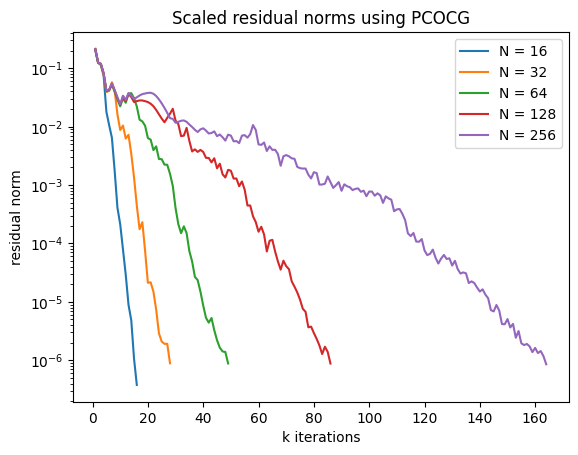

In [99]:
norms = []
ks = []

print("We are using", names[solver])
print("")
print("")

for N in N_list:
    N_x = N+1
    N_y = N+1

    dx = 1 / N
    dy = 1 / N

    matrix = build_matrix(N_x = N_x, N_y = N_y, dx = dx, dy = dy)

    vector = build_rhs(N_x = N_x, N_y = N_y, dx = dx, dy = dy)

    u0 = np.zeros(N_x*N_y, dtype=np.complex128)

    if solver == 0:
        start = time.time()
        u = direct_method(matrix, vector)
        end = time.time()

        print("For N =", N, "we obtain maximum norm =", maximum_norm(u,N+1), "taking", end - start, "seconds.")

    if solver == 1:
        start = time.time()
        u, k_list, norm_list = gauss_seidel(A = matrix, b = vector, u0 = u0)
        end = time.time()

    if solver == 2:
        start = time.time()
        u, k_list, norm_list = PCOCG(A = matrix, b = vector, u0 = u0, preconditioner = False)
        end = time.time()

    if solver == 3:
        start = time.time()
        u, k_list, norm_list = PGMRES(A = matrix, b = vector, u0 = u0, preconditioner = False)
        end = time.time()

    if solver == 4:
        start = time.time()
        u, k_list, norm_list = PCOCG(A = matrix, b = vector, u0 = u0, preconditioner = True)
        end = time.time()

    if solver == 5:
        start = time.time()
        u, k_list, norm_list = PGMRES(A = matrix, b = vector, u0 = u0, preconditioner = True)
        end = time.time()


    if solver > 0:
        ks.append(k_list)
        norms.append(norm_list)
        print("N =", N)
        print("Computation time is", end - start, "seconds.")

        reds = []
        for i in range(1,6):
            reds.append(norm_list[-i]/norm_list[-i-1])
        print("red_k for the last 5 iterations =", np.array(reds))
        print("")


if solver > 0:
    for i in range(len(norms)):
        plt.plot(ks[i], norms[i], label=f"N = {N_list[i]}")
        plt.yscale('log')
        plt.title(f"Scaled residual norms using {names[solver]}")
        plt.xlabel("k iterations")
        plt.ylabel("residual norm")
        plt.legend()
    plt.show()